In [1]:
import os

import torch
from torch import nn

from src.utils.global_constants import MODELS_DIR
from src.utils.datasets import EmbeddingDataset
from src.utils.train_test import train_class_incremental, get_study_sessions
from src.nn_modules.mlp import BaselineMLP
from src.nn_modules.kan import BaselineKAN

# The random seed is fixed to ensure reproducibility of results
torch.manual_seed(42)
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)
device

device(type='cpu')

In [2]:
# Create a directory for trained models if it doesn't exist
os.makedirs(MODELS_DIR, exist_ok=True)

#### Datasets and training parameters

In [3]:
# Offline training parameters
learning_rate = 8e-4
batch_size = 256
criterion = nn.CrossEntropyLoss()
num_epochs = 100
early_stopping = 10
base_size = 100
session_size = 1

# Precomputed elmbeddings of images from the CUB200 dataset generated by ResNet50 model
trainset = EmbeddingDataset("cub200_train_embed.pt")
testset = EmbeddingDataset("cub200_test_embed.pt")
study_sessions = get_study_sessions(testset, base_size, session_size)

#### Models definition

###### MLP:

In [4]:
mlp = BaselineMLP()
mlp_optimizer = torch.optim.NAdam(mlp.parameters(), lr=learning_rate)
mlp

BaselineMLP(
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=400, bias=True)
    (3): ReLU()
    (4): Linear(in_features=400, out_features=200, bias=True)
  )
)

###### KAN:

In [5]:
kan = BaselineKAN()
kan_optimizer = torch.optim.NAdam(kan.parameters(), lr=learning_rate)
kan

BaselineKAN(
  (classifier): KANLayer(
    (bn): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

#### Class Incremental Learning

###### MLP:

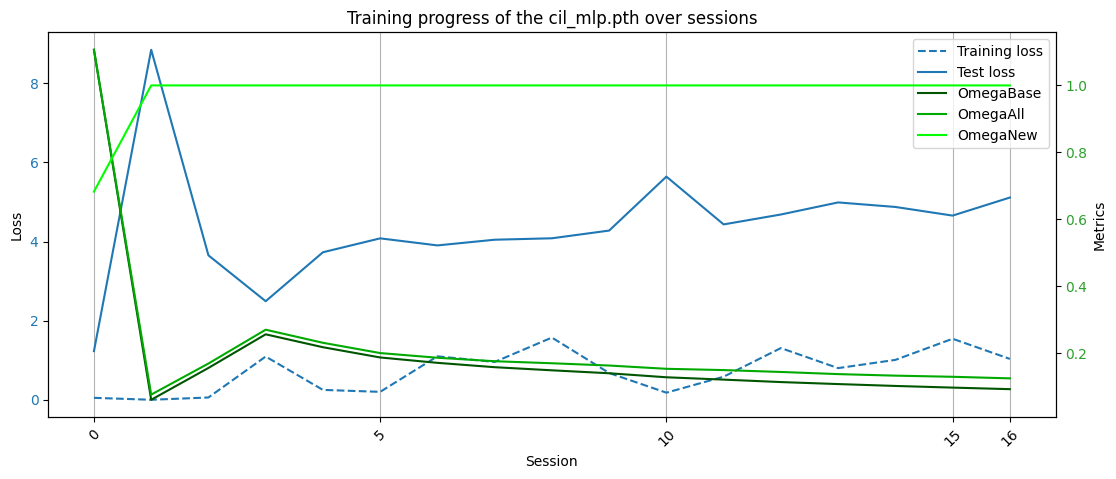

KeyboardInterrupt: 

In [6]:
train_class_incremental(
    model=mlp,
    trainset=trainset,
    testset=testset,
    criterion=criterion,
    optimizer=mlp_optimizer,
    save_path="cil_mlp.pth",
    study_sessions=study_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

###### KAN:

In [ ]:
train_class_incremental(
    model=mlp,
    trainset=trainset,
    testset=testset,
    criterion=criterion,
    optimizer=kan_optimizer,
    save_path="cil_kan.pth",
    study_sessions=study_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)